# CT Poisson transmission: SMC vs. baselines

Single experiment, one likelihood. Parallel-beam Radon transform, Beer--Lambert
transmission, Poisson counts:

$$a(x) = s\,\mathrm{softplus}(g(x+c)),\quad z = A_\Omega a(x),\quad
\lambda = N_0 e^{-z},\quad y_i \sim \mathrm{Poisson}(\lambda_i)$$

The reward $r(x)=\sum_i [y_i\log\lambda_i - \lambda_i]$ and its gradient are
the only problem-specific inputs; every method below consumes the same
`CTForward` object, so all methods provably share one posterior.

Run order: **Config → Setup → Data → Diagnostics → Methods → Results.**
Stop at the Diagnostics gate if anything fails there.

## 1. Configuration

Everything tunable lives here. No environment variables.

In [14]:
from dataclasses import dataclass, field
import pathlib

@dataclass
class Cfg:
    # -- geometry (gives m = 18432 observed rays) --------------------------
    img_size:        int   = 64
    num_angles:      int   = 20
    num_detectors:   int   = 20
    mask_fraction:   float = 1
    mask_seed:       int   = 0

    # -- photon statistics -------------------------------------------------
    n0_photons:      float = 1000.0
    # a(x) = atten_scale * link(atten_gain * (x + atten_offset))
    #
    # atten_scale sets the photon regime.  With the affine link below:
    #   4.0 -> lambda in [19, 4096], mean 940   (low-dose; some rays near zero)
    #   3.0 -> lambda in [74, 4096], mean 1240  (moderate)
    #   1.0 -> lambda in [1073, 4096]           (near-Gaussian; NOT a stress test)
    # Note the pedestal fix below roughly halves z, so the right scale here is
    # larger than it would be with the old softplus/offset=2 link.
    #
    # atten_offset sets the background pedestal, and it matters more than it
    # looks.  FBP assumes the object is compactly supported with air around it.
    # With ("softplus", 2.0) the attenuation floor is 43% of its peak, every
    # projection is truncated, and FBP correlation drops to 0.29 -- worse than
    # unfiltered backprojection.  ("affine", 1.0) gives a in [0,2] with genuine
    # air and FBP correlation 0.99.  It also makes r exactly concave in x.
    atten_scale:     float = 4.00
    atten_link:      str   = "affine"       # "affine" | "softplus"
    atten_offset:    float = 1.00           # affine: 1.0 -> air at x=-1
    atten_gain:      float = 1.00

    # -- score prior -------------------------------------------------------
    # Point this at the .pt you trained on the ellipse-phantom data.
    prior_dir:       str   = "/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs"
    checkpoint:      str   = ""     # "" -> prior_dir/score_prior_singlecoil_mri_64_trained.pt
    base_channels:   int   = 32     # BASE_CHANNELS in your notebook
    time_emb_dim:    int   = 128    # TIME_EMB_DIM in your notebook (NOT 64)

    # -- ground truth (same distribution the prior was trained on) ---------
    truth_index:     int   = 0
    truth_seed:      int   = 12345  # != training seed, so this image is unseen

    # -- sampling ----------------------------------------------------------
    n_samples:       int   = 512
    n_steps:         int   = 200      # DPS reverse-SDE steps
    seed:            int   = 0
    reward_chunk:    int   = 8
    angle_chunk:     int   = 20

    # -- SMC ---------------------------------------------------------------
    smc_levels:      int   = 5
    smc_ref_levels:  int   = 8
    smc_steps:       tuple = (100, 120, 140, 160, 180, 200, 220, 240)
    smc_n_ref_tail:  int   = 256
    smc_surrogate:   str   = "none"    # none | inv_m | inv_sqrt_m
    smc_tail_stats:  str   = ""       # "" -> prior_dir/score_prior_tail_behavior_stats.npz

    # -- output ------------------------------------------------------------
    outdir:          str   = "ct_poisson_outputs"
    save_figures:    bool  = True

cfg = Cfg()

# Resolve the two files that live next to the trained prior.  Same glob-and-
# take-newest logic as AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT in your notebook,
# because the checkpoint filename is not fixed.
def _latest(directory, patterns):
    """First pattern that matches wins; newest file within that pattern.

    Pattern order is priority order, so a specific '*_trained.pt' beats a
    generic '*.pt' even if some other checkpoint in the folder is newer.
    """
    d = pathlib.Path(directory).expanduser()
    if not d.exists():
        return None
    for pat in patterns:
        hits = [p for p in d.glob(pat) if p.is_file()]
        if hits:
            return max(hits, key=lambda p: p.stat().st_mtime)
    return None

_pd = pathlib.Path(cfg.prior_dir).expanduser()
if not cfg.checkpoint:
    _ck = _latest(_pd, ["score_prior*_trained.pt", "score_prior_singlecoil_mri_*.pt",
                        "score_prior*.pt", "*.pt"])
    cfg.checkpoint = str(_ck) if _ck else ""
if not cfg.smc_tail_stats:
    _ts = _latest(_pd, ["score_prior_tail_behavior_stats*.npz", "*tail*stats*.npz"])
    cfg.smc_tail_stats = str(_ts) if _ts else ""

OUT = pathlib.Path(cfg.outdir); OUT.mkdir(parents=True, exist_ok=True)
print("prior dir  :", _pd, " exists:", _pd.exists())
print("checkpoint :", cfg.checkpoint or "(NONE FOUND)")
print("tail stats :", cfg.smc_tail_stats or "(will recompute)")
if _pd.exists() and not cfg.checkpoint:
    print()
    print("  .pt files present in prior_dir:")
    for p in sorted(_pd.rglob("*.pt")):
        print("   ", p)
    print("  set cfg.checkpoint to one of these explicitly.")
cfg



prior dir  : /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs  exists: True
checkpoint : /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
tail stats : /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz


Cfg(img_size=64, num_angles=20, num_detectors=20, mask_fraction=1, mask_seed=0, n0_photons=1000.0, atten_scale=4.0, atten_link='affine', atten_offset=1.0, atten_gain=1.0, prior_dir='/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs', checkpoint='/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt', base_channels=32, time_emb_dim=128, truth_index=0, truth_seed=12345, n_samples=512, n_steps=200, seed=0, reward_chunk=8, angle_chunk=20, smc_levels=5, smc_ref_levels=8, smc_steps=(100, 120, 140, 160, 180, 200, 220, 240), smc_n_ref_tail=256, smc_surrogate='none', smc_tail_stats='/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz', outdir='ct_poisson_outputs', save_figures=True)

## 2. Setup

Builds the forward model and the score prior.

In [15]:
# Pick up edits to the local .py files without restarting the kernel.
# Without this, `import` caches on first use and a re-downloaded module is
# silently ignored -- the usual cause of "module has no attribute X".
%load_ext autoreload
%autoreload 2

import importlib, sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import math, time, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

import ct_forward, ct_common, ct_smc
for _m in (ct_forward, ct_common, ct_smc):
    importlib.reload(_m)
from ct_forward import CTConfig, CTForward
common = ct_common

# Fail loudly now rather than 20 cells later if a stale copy is on the path.
_required = [(ct_common, "build_score_model_for_checkpoint"),
             (ct_common, "sample_cylinder_image"),
             (ct_forward.CTForward, "set_reference_from_counts"),
             (ct_smc, "run_multilevel_smc_scoreprior")]
_missing = [f"{getattr(o, '__name__', o)}.{a}" for o, a in _required if not hasattr(o, a)]
if _missing:
    for _m in (ct_forward, ct_common, ct_smc):
        print(f"  {_m.__name__:12s} {_m.__file__}")
    raise ImportError(
        "Stale module(s) on the path; missing: " + ", ".join(_missing) +
        ". Overwrite the .py files above with the current versions, then "
        "Kernel -> Restart & Run All.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)

ct = CTForward(CTConfig(
    img_size=cfg.img_size,
    num_angles=cfg.num_angles,
    num_detectors=cfg.num_detectors,
    mask_type="vd_poisson",
    mask_fraction=cfg.mask_fraction,
    mask_seed=cfg.mask_seed,
    n0_photons=cfg.n0_photons,
    attenuation_link=cfg.atten_link,
    attenuation_scale=cfg.atten_scale,
    attenuation_offset=cfg.atten_offset,
    attenuation_gain=cfg.atten_gain,
    angle_chunk=cfg.angle_chunk,
), DEVICE)

# Build the network sized to the checkpoint rather than to cfg, so a stale
# base_channels / time_emb_dim cannot silently mismatch the trained weights.
score_model = None
if cfg.checkpoint and pathlib.Path(cfg.checkpoint).expanduser().exists():
    score_model, _dims = common.build_score_model_for_checkpoint(cfg.checkpoint, DEVICE)
    cfg.base_channels, cfg.time_emb_dim = _dims["base_ch"], _dims["emb_dim"]
    print("loaded checkpoint:", cfg.checkpoint)
    print("  architecture from checkpoint:", _dims)

if score_model is None:
    score_model = common.build_score_model(cfg.base_channels, cfg.time_emb_dim, DEVICE)
    warnings.warn(f"Checkpoint not found at {cfg.checkpoint!r} - the score prior is "
                  "RANDOMLY INITIALISED. Results are meaningless; this mode only "
                  "verifies the plumbing.")
score_model.eval()
print("score model parameters:",
      round(sum(p.numel() for p in score_model.parameters()) / 1e6, 4), "M")

print(ct.summary())
print("device:", DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  checkpoint metadata: {'global_step': 109000, 'saved_at_unix_time': 1783806897.8026702, 'config': {'SEED': 2026, 'DATA_MODE': 'fastmri_h5', 'IMG_SIZE': 64, 'NUM_TRAIN_STEPS': 50000, 'BASE_CHANNELS': 32, 'TIME_EMB_DIM': 128}}
loaded checkpoint: /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
  architecture from checkpoint: {'emb_dim': 128, 'base_ch': 32, 'in_ch': 1}
score model parameters: 0.5626 M
CT parallel-beam | 20 angles x 20 detectors over [0,180.0) deg
  mask=vd_poisson  m=400/400 (1.000)
  link=affine (s,g,c)=(4.0,1.0,1.0)  pixel_size=0.03125
  N0=1000.0  background=0.0
device: cuda


## 3. Ground truth and observation

`cfg.truth_index` picks which phantom from the training distribution to
reconstruct. Change it to check the result is not specific to one image.

In [16]:
# Same synthetic ellipse-phantom distribution the prior was trained on
# (SyntheticMRIDataset in the original notebooks). Using an in-distribution
# test image matters: an ad-hoc phantom confounds sampler quality with prior
# mismatch, and the SMC would look worse than it is.
x_true = common.sample_cylinder_image(
    index=cfg.truth_index, img_size=cfg.img_size,
    seed=cfg.truth_seed, device=DEVICE)

gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed)
y_obs, lam_true = ct.simulate_observation(x_true, sample_counts=True, generator=gen)
# simulate_observation also fixes the reward centring reference. Required.

print("x_true:", tuple(x_true.shape), "range",
      (float(x_true.min()), float(x_true.max())))
print("y_obs :", tuple(y_obs.shape), "counts", (float(y_obs.min()), float(y_obs.max())))

x_true: (1, 1, 64, 64) range (-1.0, 0.9999989867210388)
y_obs : (400,) counts (5.0, 671.0)


## 4. Diagnostics gate

Three checks. **Do not proceed past a failure**; every method downstream
inherits whatever is wrong here.

1. **Regime report** — the numbers the paper needs to substantiate a low-count
   claim. If `lambda_mean` is in the thousands you are in the near-Gaussian
   regime, whatever the text says.
2. **Gradient check** — finite difference vs. autodiff, in float64.
3. **Fingerprint** — hash of config + mask + data. Any other notebook claiming
   to solve this problem must print the same string.

In [17]:
rep = ct.regime_report(x_true, y_obs)
for k, v in rep.items():
    print(f"  {k:22s} {v:.4f}" if isinstance(v, float) else f"  {k:22s} {v}")

chk = ct.check_gradient(x_true, y_obs)
print(f"\n  grad median rel err  {chk['median_relative_error']:.2e}"
      f"   ||grad r||  {chk['grad_norm']:.3e}")
assert chk["median_relative_error"] < 5e-2, chk

print("\n  FINGERPRINT:", ct.fingerprint(y_obs=y_obs, x_true=x_true))

_ped = rep["a_min"] / max(rep["a_max"], 1e-12)
print()
print(f"  attenuation pedestal a_min/a_max = {_ped:.3f}"
      "   (0 = genuine air; > ~0.3 breaks FBP)")
if _ped > 0.3:
    warnings.warn(f"Pedestal {_ped:.2f}: the object is not compactly supported, "
                  "so every projection is truncated and FBP will underperform "
                  "even plain backprojection. Use atten_link='affine', "
                  "atten_offset=1.0 for air at x=-1.")

if rep["lambda_mean"] > 1000:
    warnings.warn(f"lambda_mean={rep['lambda_mean']:.0f}: near-Gaussian regime. "
                  "Lower cfg.atten_scale for a genuine Poisson stress test.")

  obs_dim_m              400
  grid                   (20, 20)
  observed_fraction      1.0000
  a_min                  0.0000
  a_max                  8.0000
  z_min                  0.4555
  z_mean                 1.9491
  z_max                  5.3113
  lambda_min             4.9353
  lambda_mean            268.4633
  lambda_max             634.1019
  frac_zero_counts       0.0000
  frac_counts_below_10   0.0550

  grad median rel err  1.41e-04   ||grad r||  2.146e+02

  FINGERPRINT: 278ac8bd1c323893

  attenuation pedestal a_min/a_max = 0.000   (0 = genuine air; > ~0.3 breaks FBP)


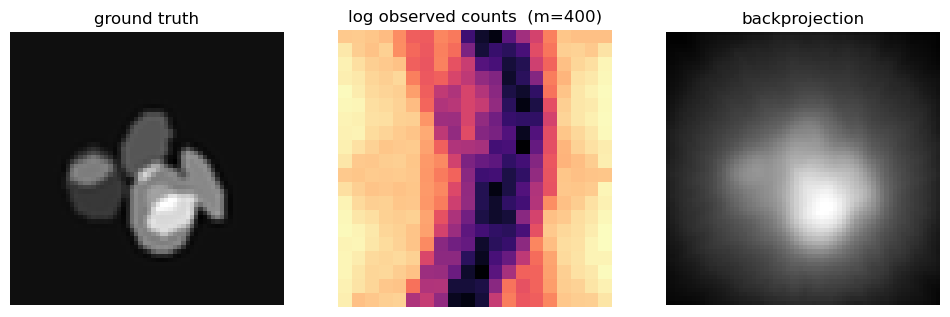

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1); ax[0].set_title("ground truth")
ax[1].imshow(ct.display_sinogram(y_obs).cpu(), cmap="magma", aspect="auto")
ax[1].set_title(f"log observed counts  (m={ct.obs_dim})")
ax[2].imshow(ct.backproject_from_counts(y_obs)[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
ax[2].set_title("backprojection")
for a in ax: a.axis("off")
if cfg.save_figures: fig.savefig(OUT / "observation.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Methods

Every method obeys one contract:

```python
def method(model, ct, y_obs, cfg, seed) -> torch.Tensor   # (n_samples, 1, H, W) in [-1,1]
```

`ct.reward(x, y_obs)` gives $r$ for a batch of particles; wrap it in
`torch.autograd.grad` for $\nabla r$. Nothing else is problem-specific.

In [19]:
METHODS = {}

def register(name):
    def deco(fn):
        METHODS[name] = fn
        return fn
    return deco


def reward_and_grad(x, ct, y_obs):
    """(r, grad r) for a batch of particles. The oracle every method shares."""
    x = x.detach().requires_grad_(True)
    r = ct.reward(x, y_obs)
    g = torch.autograd.grad(r.sum(), x)[0]
    return r.detach(), g

### 5a. Classical reconstruction (deterministic reference)

FBP with a Hann-windowed ramp filter, plus plain backprojection for contrast.
Unobserved rays are interpolated rather than zero-filled -- a ramp filter reads
zeros as "no attenuation here" and streaks.

In [20]:
@register("FBP")
def method_fbp(model, ct, y_obs, cfg, seed):
    return ct.fbp_from_counts(y_obs, window="hann")


@register("Backprojection")
def method_backprojection(model, ct, y_obs, cfg, seed):
    return ct.backproject_from_counts(y_obs)

### 5b. DPS (Diffusion Posterior Sampling)

Self-contained reverse-SDE sampler with a likelihood-gradient correction at each
step. Step size is normalised by $\|\nabla r\|$, which matters here because
$r$ is order $10^6$ at $m=18432$ and a raw step size would not transfer.

In [21]:
@register("DPS")
def method_dps(model, ct, y_obs, cfg, seed, step_scale=1.0, grad_clip=1.0):
    N, H = cfg.n_samples, cfg.img_size
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    x = torch.randn(N, 1, H, H, device=DEVICE, generator=g)

    ts = torch.linspace(1.0, 1e-3, cfg.n_steps + 1, device=DEVICE)
    for i in range(cfg.n_steps):
        t, t_next = ts[i], ts[i + 1]
        dt = (t - t_next)
        tb = t.expand(N)

        with torch.no_grad():
            score = model(x, tb)

        # reverse diffusion step (VP-SDE: mean=(1-t), std=sqrt(t(2-t)))
        drift = -x / torch.clamp(1.0 - t, min=1e-3)
        noise = torch.randn(x.shape, device=DEVICE, generator=g)
        x = x + (drift - 2.0 * score) * (-dt) + torch.sqrt(2.0 * dt) * noise

        # likelihood correction, normalised by gradient magnitude
        _, gr = reward_and_grad(x, ct, y_obs)
        gn = gr.flatten(1).norm(dim=1).view(-1, 1, 1, 1).clamp(min=1e-12)
        x = (x + step_scale * float(dt) * (gr / gn) * math.sqrt(H * H)).detach()
        x = x.clamp(-3.0, 3.0)

    return x.clamp(-1.0, 1.0).detach()

### 5c. Multilevel SMC (the proposed method)

`ct_smc.py` holds the sampler: multiscale level expansion, base/increment
reverse-SDE simulators, the first-order surrogate
$L_m(x) = r(x) + c_m\eta_m\langle\nabla r(x), \mu_{>m}\rangle$, and branch/kill
resampling. Bodies are ported verbatim from your notebook; only the reward
oracle changed.

**Likelihood tempering is auto-calibrated.** At $m \sim 10^4$ the reward spread
across prior particles is order $10^4$--$10^5$, so raw weights put all mass on
one particle and every level collapses to a single ancestor. The sampler
bisects for the strength that puts level-0 ESS at half the particle count.
Set `auto_calibrate_strength=False` to override.

In [22]:
from ct_smc import run_multilevel_smc_scoreprior, SMCConfig

@register("SMC (ours)")
def method_smc(model, ct, y_obs, cfg, seed):
    smc_cfg = SMCConfig(
        img_size=cfg.img_size,
        num_smc_levels=cfg.smc_levels,
        num_ref_levels=cfg.smc_ref_levels,
        n_steps_ref_by_level=list(cfg.smc_steps),
        n_ref_tail=cfg.smc_n_ref_tail,
        surrogate_mode=cfg.smc_surrogate,
        surrogate_chunk_size=cfg.reward_chunk,
        tail_stats_path=cfg.smc_tail_stats,
    )
    out = run_multilevel_smc_scoreprior(
        model, ct=ct, y_obs=y_obs, n_particles=cfg.n_samples, seed=seed,
        cfg=smc_cfg)
    globals()["smc_out"] = out          # keep diagnostics for the next cell
    return out["samples"]
# SMCConfig(auto_calibrate_strength=False, likelihood_strength=1.0)

## 6. Run all methods

In [23]:
def psnr(a, b, data_range=2.0):
    mse = torch.mean((a - b) ** 2)
    return float(10.0 * torch.log10(data_range ** 2 / torch.clamp(mse, min=1e-12)))

results = {}
for name, fn in METHODS.items():
    t0 = time.time()
    samples = fn(score_model, ct, y_obs, cfg, cfg.seed)
    dt = time.time() - t0
    mean = samples.mean(0, keepdim=True)
    with torch.no_grad():
        r = ct.reward(samples, y_obs)
    res = ct.residual_summary(samples, y_obs)          # per-sample, then averaged
    res_mean = ct.residual_summary(mean, y_obs)        # of the posterior mean
    results[name] = dict(
        samples=samples, mean=mean, seconds=dt,
        rmse=float(torch.sqrt(torch.mean((mean - x_true) ** 2))),
        psnr=psnr(mean, x_true),
        pearson_rms=res["pearson_rms_mean"],
        pearson_rms_std=res.get("pearson_rms_std", float("nan")),
        deviance=res["deviance_per_ray_mean"],
        count_rmse=res["count_rmse_mean"],
        pearson_rms_of_mean=res_mean["pearson_rms_mean"],
        reward_mean=float(r.mean()),
        post_std=float(samples.std(0).mean()) if samples.shape[0] > 1 else float("nan"),
        n=int(samples.shape[0]),
    )
    print(f"{name:18s} {dt:7.1f}s   rmse={results[name]['rmse']:.4f}   "
          f"psnr={results[name]['psnr']:6.2f}   "
          f"pearson={results[name]['pearson_rms']:6.3f}   "
          f"r={results[name]['reward_mean']:.4e}")

# Reference: the ground truth itself. Any method whose Pearson RMS is much
# below this is fitting the noise realisation, not the object.
_ref = ct.residual_summary(x_true, y_obs)
print()
print(f"{'ground truth':18s} {'(reference)':>26s}   "
      f"pearson={_ref['pearson_rms_mean']:6.3f}   (target: ~1.0)")

FBP                    0.0s   rmse=0.1218   psnr= 24.31   pearson= 5.633   r=-7.1533e+03
Backprojection         0.0s   rmse=0.3970   psnr= 14.05   pearson=48.263   r=-1.1468e+05
DPS                    7.3s   rmse=0.2476   psnr= 18.14   pearson=24.703   r=-4.6168e+04
loading tail stats: /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz
calibrated likelihood_strength = 1.740e-04  (level-0 ESS 32.0/64, reward spread 2.12e+04)
MULTILEVEL SMC  levels: 5  steps: [100, 120, 140, 160, 180]
eta_by_level: ['0.8642', '0.7483', '0.6784', '0.6368', '0.5173']
likelihood_strength: 1.740e-04
surrogate: none  multiplier: 0.000e+00  m: 400
level 1/5: N=521 ESS=266.4/512 unique=342
level 2/5: N=513 ESS=313.6/521 unique=371
level 3/5: N=494 ESS=302.8/513 unique=367
level 4/5: N=505 ESS=393.3/494 unique=404
level 5/5: N=501 ESS=445.1/505 unique=446
SMC (ours)            52.8s   rmse=0.2456   psnr= 18.21   pearson= 7.876   r=-1.4965e+04

ground truth   

### SMC level diagnostics

ESS per level is the health check. Sustained ESS well below the particle count,
or a unique-ancestor count in the single digits, means the level increments are
too coarse or the tempering is wrong -- not that the method failed.

 level      N       ESS   unique        eta
     1    521     266.4      342     0.8642
     2    513     313.6      371     0.7483
     3    494     302.8      367     0.6784
     4    505     393.3      404     0.6368
     5    501     445.1      446     0.5173


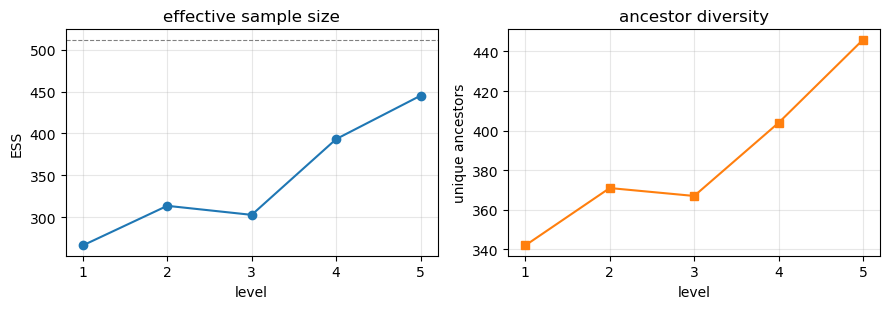

In [27]:
if "smc_out" in globals():
    o = smc_out
    print(f"{'level':>6} {'N':>6} {'ESS':>9} {'unique':>8} {'eta':>10}")
    for i, (n, e, u, et) in enumerate(zip(o["pop_by_level"], o["ess_by_level"],
                                          o["unique_ancestors"], o["eta_by_level"]), 1):
        print(f"{i:>6} {n:>6} {e:>9.1f} {u:>8} {et:>10.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    lv = range(1, len(o["ess_by_level"]) + 1)
    ax[0].plot(lv, o["ess_by_level"], "o-"); ax[0].set_xlabel("level"); ax[0].set_ylabel("ESS")
    ax[0].axhline(cfg.n_samples, ls="--", c="gray", lw=0.8); ax[0].set_title("effective sample size")
    ax[1].plot(lv, o["unique_ancestors"], "s-", c="C1")
    ax[1].set_xlabel("level"); ax[1].set_ylabel("unique ancestors"); ax[1].set_title("ancestor diversity")
    for a in ax: a.grid(alpha=0.3)
    fig.tight_layout()
    if cfg.save_figures: fig.savefig(OUT / "smc_levels.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Comparison

In [25]:
import pandas as pd
_cols = ["rmse", "psnr", "pearson_rms", "pearson_rms_std", "pearson_rms_of_mean",
         "deviance", "count_rmse", "reward_mean", "post_std", "n", "seconds"]
df = pd.DataFrame({k: {m: v[m] for m in _cols} for k, v in results.items()}).T
df.loc["(ground truth)", "pearson_rms"] = _ref["pearson_rms_mean"]
df.loc["(ground truth)", "deviance"] = _ref["deviance_per_ray_mean"]
df.index.name = "method"
df.to_csv(OUT / "comparison.csv")
df

,rmse,psnr,pearson_rms,pearson_rms_std,pearson_rms_of_mean,deviance,count_rmse,reward_mean,post_std,n,seconds
method,,,,,,,,,,,
FBP,0.121782,24.308947,5.633121,NaN,5.633121,35.766613,137.910889,-7153.322266,NaN,1.0,0.002616
Backprojection,0.396955,14.045763,48.262703,NaN,48.262703,573.393555,251.098724,-114678.710938,NaN,1.0,0.000881
DPS,0.247629,18.144569,24.702856,6.763583,17.775167,230.841461,182.722305,-46168.292969,0.428244,512.0,7.257507
SMC (ours),0.245644,18.214464,7.875636,1.654002,5.767954,74.826996,129.657471,-14965.398438,0.097451,501.0,52.782864
(ground truth),NaN,NaN,0.992914,NaN,NaN,0.986407,NaN,NaN,NaN,NaN,NaN


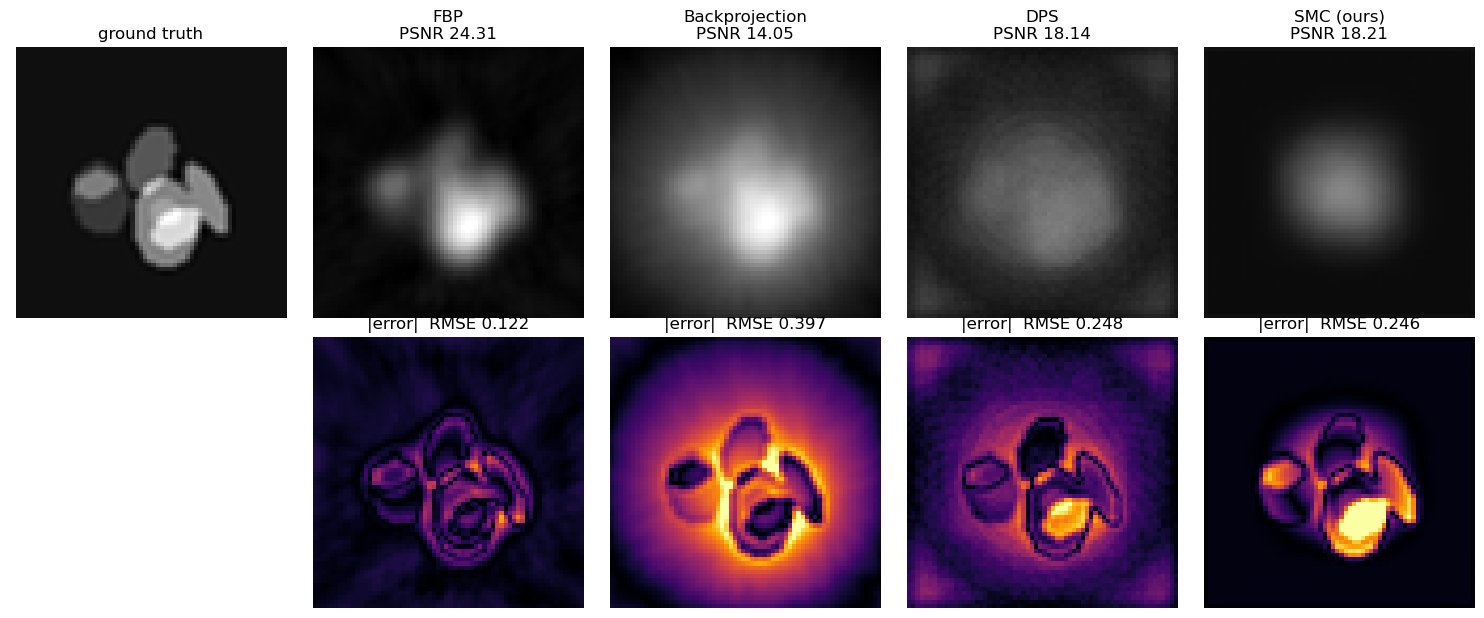

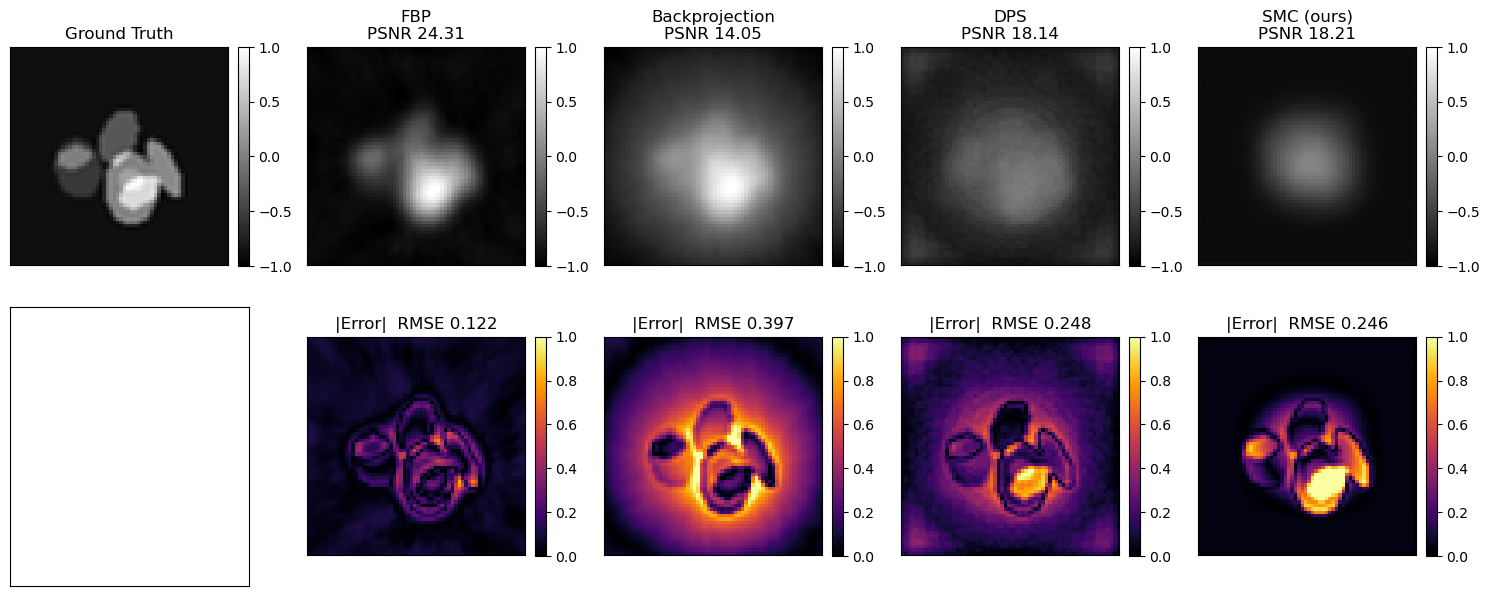

In [28]:
k = len(results)
fig, ax = plt.subplots(2, k + 1, figsize=(3.0 * (k + 1), 6.2))
ax[0, 0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
ax[0, 0].set_title("ground truth"); ax[1, 0].axis("off")
for j, (name, r) in enumerate(results.items(), start=1):
    ax[0, j].imshow(r["mean"][0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    ax[0, j].set_title(f"{name}\nPSNR {r['psnr']:.2f}")
    err = (r["mean"] - x_true)[0, 0].abs().detach().cpu()
    im = ax[1, j].imshow(err, cmap="inferno", vmin=0, vmax=1.0)
    ax[1, j].set_title(f"|error|  RMSE {r['rmse']:.3f}")
for a in ax.ravel(): a.axis("off")
fig.tight_layout()
if cfg.save_figures: fig.savefig(OUT / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()

k = len(results)
fig, ax = plt.subplots(2, k + 1, figsize=(3.0 * (k + 1), 6.2))

# Ground truth
im0 = ax[0, 0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
ax[0, 0].set_title("Ground Truth")

# Optional: colorbar for ground truth
fig.colorbar(im0, ax=ax[0, 0], fraction=0.046, pad=0.04)

for j, (name, r) in enumerate(results.items(), start=1):
    # Reconstruction
    im1 = ax[0, j].imshow(
        r["mean"][0, 0].detach().cpu(),
        cmap="gray",
        vmin=-1,
        vmax=1
    )
    ax[0, j].set_title(f"{name}\nPSNR {r['psnr']:.2f}")
    fig.colorbar(im1, ax=ax[0, j], fraction=0.046, pad=0.04)

    # Error map
    err = (r["mean"] - x_true)[0, 0].abs().detach().cpu()
    im2 = ax[1, j].imshow(
        err,
        cmap="inferno",
        vmin=0,
        vmax=1.0
    )
    ax[1, j].set_title(f"|Error|  RMSE {r['rmse']:.3f}")
    fig.colorbar(im2, ax=ax[1, j], fraction=0.046, pad=0.04)

# Hide ticks but keep images and colorbars
for a in ax.ravel():
    a.set_xticks([])
    a.set_yticks([])

fig.tight_layout()

if cfg.save_figures:
    fig.savefig(OUT / "comparison.png", dpi=150, bbox_inches="tight")

plt.show()

## 8. Top-5 MAP particles

The highest-reward particles from each method, which is what the sampler would
report if asked for a point estimate. Ranked by $r(x)$.

Duplicates are suppressed two ways. For SMC, at most one particle per unique
**ancestor lineage** -- otherwise branch/kill fills the top of the ranking with
copies of one successful particle and the panel looks like five identical
images. For methods without lineage information, near-identical images are
collapsed by a rounded content hash. A single image is repeated to fill the row
only when there is genuinely just one distinct particle, and the panel says so.

In [29]:
NUM_MAP_PARTICLES = 5
MAP_DISTINCT_ATOL = 1e-7


def _content_key(x, atol=MAP_DISTINCT_ATOL):
    a = x.detach().cpu().reshape(-1).numpy()
    return (np.round(a / atol).astype(np.int64) if atol else a.astype(np.float32)).tobytes()


@torch.no_grad()
def topk_map_particles(samples, ct, y_obs, k=NUM_MAP_PARTICLES, ancestor_ids=None):
    """Top-k distinct particles by reward. Returns (rewards, samples, meta)."""
    n = int(samples.shape[0])
    if n == 0:
        raise ValueError("empty sample cloud")
    rewards = ct.reward(samples, y_obs).detach()
    order = torch.argsort(rewards, descending=True)

    anc = None
    if ancestor_ids is not None:
        anc = np.asarray(ancestor_ids).reshape(-1)
        if len(anc) != n:
            print(f"  ancestor_ids length {len(anc)} != {n}; using content hashing")
            anc = None

    picked, seen_anc, seen_key = [], set(), set()
    for i in order.tolist():
        if anc is not None:
            a = int(anc[i])
            if a in seen_anc:
                continue
            seen_anc.add(a)
        key = _content_key(samples[i])
        if key in seen_key:
            continue
        seen_key.add(key)
        picked.append(i)
        if len(picked) >= k:
            break

    repeated = False
    if len(picked) == 1 and k > 1:
        picked = picked * k              # only ever repeat a genuine singleton
        repeated = True

    idx = torch.as_tensor(picked, dtype=torch.long, device=samples.device)
    meta = dict(n_distinct=len(set(picked)), n_displayed=len(picked),
                repeated_single=repeated,
                n_unique_ancestors=int(len(np.unique(anc))) if anc is not None else None)
    return rewards[idx], samples[idx], meta

DPS                5 distinct
SMC (ours)         5 distinct, 193 unique lineages


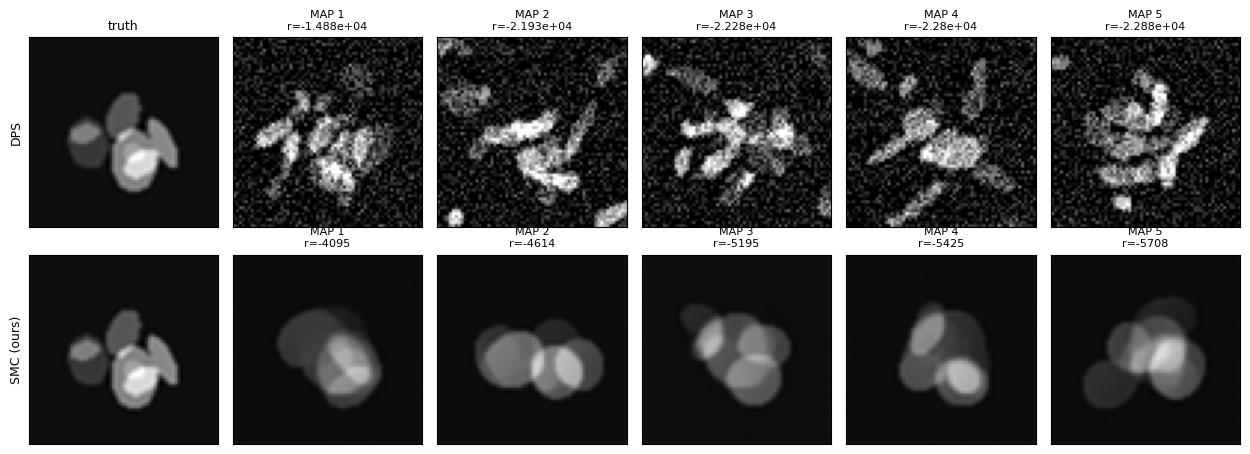

In [30]:
map_results = {}
for name, r in results.items():
    if r["samples"].shape[0] < 2:
        continue                      # deterministic methods have nothing to rank
    anc = smc_out.get("ancestors") if (name.startswith("SMC") and "smc_out" in globals()) else None
    rw, mp, meta = topk_map_particles(r["samples"], ct, y_obs, ancestor_ids=anc)
    map_results[name] = (rw, mp, meta)
    tag = "  (single particle repeated)" if meta["repeated_single"] else ""
    anc_tag = f", {meta['n_unique_ancestors']} unique lineages" if meta["n_unique_ancestors"] else ""
    print(f"{name:18s} {meta['n_distinct']} distinct{anc_tag}{tag}")

if map_results:
    nrow = len(map_results)
    fig, ax = plt.subplots(nrow, NUM_MAP_PARTICLES + 1,
                           figsize=(2.1 * (NUM_MAP_PARTICLES + 1), 2.3 * nrow),
                           squeeze=False)
    for i, (name, (rw, mp, meta)) in enumerate(map_results.items()):
        ax[i, 0].imshow(x_true[0, 0].cpu(), cmap="gray", vmin=-1, vmax=1)
        ax[i, 0].set_ylabel(name, fontsize=9)
        ax[i, 0].set_title("truth" if i == 0 else "", fontsize=9)
        for j in range(NUM_MAP_PARTICLES):
            a = ax[i, j + 1]
            if j < mp.shape[0]:
                a.imshow(mp[j, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
                a.set_title(f"MAP {j+1}\nr={float(rw[j]):.4g}", fontsize=8)
            else:
                a.set_visible(False)
        for a in ax[i]:
            a.set_xticks([]); a.set_yticks([])
    fig.tight_layout()
    if cfg.save_figures:
        fig.savefig(OUT / "top5_map_particles.png", dpi=150, bbox_inches="tight")
    plt.show()

### Measurement-space residuals

`rmse` and `psnr` need a ground truth you will not have on real data.
`pearson_rms` does not -- it asks whether a sample explains the observed counts,
which is exactly what the likelihood constrains.

Because the noise is Poisson with known rate, it is self-normalising:
$\sqrt{\frac{1}{m}\sum_i (y_i-\lambda_i)^2/\lambda_i} \approx 1$ for a sample from
the true posterior. Above 1 means underfitting; **below 1 means the sample is
fitting the noise realisation**, which image-space RMSE will not reveal. Read it
against the `(ground truth)` row.

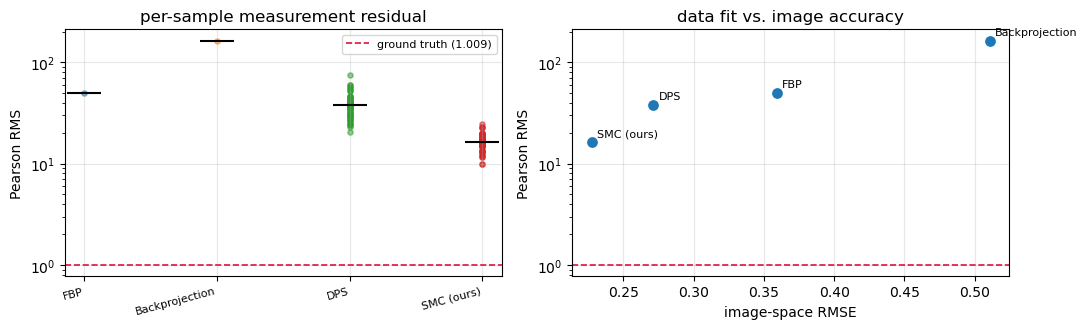

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
names = list(results.keys())

for i, name in enumerate(names):
    pr = ct.measurement_residuals(results[name]["samples"], y_obs)["pearson_rms"]
    ax[0].scatter([i] * len(pr), pr.cpu(), s=14, alpha=0.55)
    ax[0].scatter([i], [float(pr.mean())], marker="_", s=600, c="k", zorder=3)
ax[0].axhline(_ref["pearson_rms_mean"], ls="--", c="crimson", lw=1.2,
              label=f"ground truth ({_ref['pearson_rms_mean']:.3f})")
ax[0].set_xticks(range(len(names)))
ax[0].set_xticklabels(names, rotation=15, ha="right", fontsize=8)
ax[0].set_ylabel("Pearson RMS"); ax[0].set_yscale("log")
ax[0].set_title("per-sample measurement residual"); ax[0].legend(fontsize=8)

ax[1].scatter([results[n]["rmse"] for n in names],
              [results[n]["pearson_rms"] for n in names], s=45)
for n in names:
    ax[1].annotate(n, (results[n]["rmse"], results[n]["pearson_rms"]),
                   fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].axhline(_ref["pearson_rms_mean"], ls="--", c="crimson", lw=1.2)
ax[1].set_xlabel("image-space RMSE"); ax[1].set_ylabel("Pearson RMS")
ax[1].set_yscale("log"); ax[1].set_title("data fit vs. image accuracy")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout()
if cfg.save_figures: fig.savefig(OUT / "residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Posterior sampling quality

Four axes. No single number separates a good sampler from a bad one -- a method
can ace any one while failing badly on another, so read them together.

| axis | metric | target | what it catches |
|---|---|---|---|
| data fit | `chi2_per_ray` | **1.0**, not 0 | `< 1` = fitted the noise; `>> 1` = inconsistent with the counts |
| prior typicality | `dsm_z` | ~0 | likelihood dragged samples off the learned manifold |
| diversity | `participation_ratio` | large | `0` = collapsed to one image |
| calibration | `contraction_ratio` | 1.0 | `< 1` = overconfident spread |

`contraction_ratio` is RMS(posterior sd) / RMS(mean - truth): does the reported
uncertainty match the actual error? It is the one that catches a sampler
looking healthy on the other three and still lying about its confidence.

`participation_ratio` is the effective number of directions the cloud explores,
from the covariance spectrum. It beats a pixel standard deviation, which stays
large even when the cloud is N copies of two images.

`dsm_z` needs a **trained** prior. With a random-init checkpoint it is noise.

In [37]:
import ct_metrics as metrics
importlib.reload(metrics)

# Genuine prior draws, as the reference distribution for typicality.
prior_ref = torch.cat([common.sample_cylinder_image(i, cfg.img_size, seed=999, device=DEVICE)
                       for i in range(16)])

reports = {}
for name, r in results.items():
    if r["samples"].shape[0] < 2:
        continue
    reports[name] = metrics.posterior_report(
        ct, score_model, r["samples"], y_obs, x_true, prior_ref, seed=cfg.seed)

print(metrics.format_report(reports))

metric                         DPS  SMC (ours)   target
----------------------------------------------------------
chi2_per_ray                  2269       263.6   = 1  (< 1 means the noise was fitted)
chi2_z                   2.435e+05   2.818e+04   |z| < ~3
dsm_z                        47.35      -1.795   ~0  (large = off the prior manifold)
participation_ratio          48.99       8.129   large  (1.0 = collapsed)
distinct_fraction                1      0.9672   -> 1
contraction_ratio            1.812       0.636   = 1  (< 1 = overconfident)
coverage_90                      1      0.3455   -> 0.90


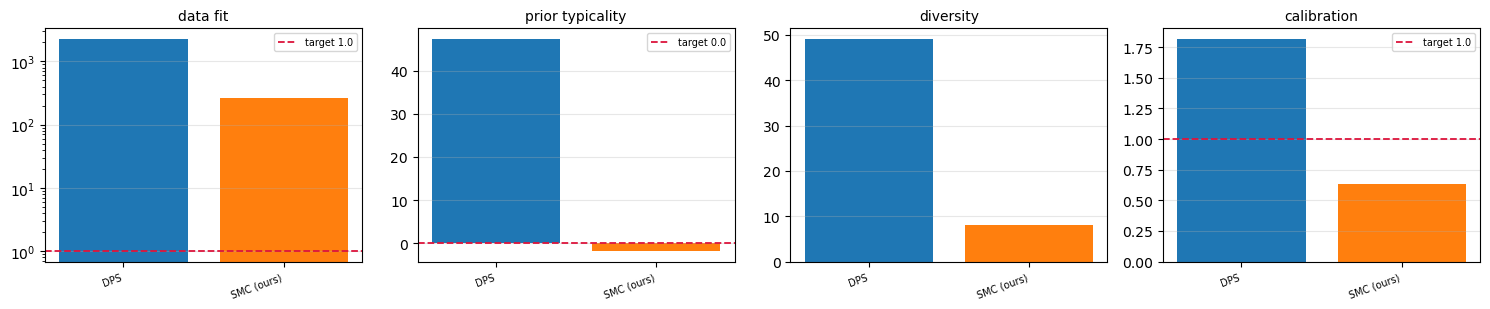

In [38]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
names = list(reports)
panels = [("chi2_per_ray", 1.0, "data fit", True),
          ("dsm_z", 0.0, "prior typicality", False),
          ("participation_ratio", None, "diversity", False),
          ("contraction_ratio", 1.0, "calibration", False)]
for a, (key, target, title, logy) in zip(ax, panels):
    vals = [reports[n][key] for n in names]
    a.bar(range(len(names)), vals, color=[f"C{i}" for i in range(len(names))])
    if target is not None:
        a.axhline(target, ls="--", c="crimson", lw=1.3, label=f"target {target}")
        a.legend(fontsize=7)
    if logy and min(vals) > 0:
        a.set_yscale("log")
    a.set_xticks(range(len(names)))
    a.set_xticklabels(names, rotation=20, ha="right", fontsize=7)
    a.set_title(title, fontsize=10); a.grid(alpha=0.3, axis="y")
fig.tight_layout()
if cfg.save_figures: fig.savefig(OUT / "posterior_quality.png", dpi=150, bbox_inches="tight")
plt.show()

### Simulation-based calibration (optional, expensive)

The four axes above can fail to reject a bad sampler. SBC can actually certify
one: draw $x^\star$ from the prior, simulate $y$, sample, and record the rank of
$x^\star$ among the samples. Under exact posterior sampling that rank is
**uniform**. A U-shaped histogram means the posterior is too narrow, a peaked
one too wide, a skewed one biased.

Costs `n_trials` full sampler runs, so use reduced settings. Set `RUN_SBC=True`.

In [ ]:
RUN_SBC = False        # set True to run; costs n_trials full sampler runs

if RUN_SBC:
    def _prior_draw(s):
        return common.sample_cylinder_image(0, cfg.img_size, seed=s, device=DEVICE)

    def _sampler(y_k, n, s):
        return METHODS["SMC (ours)"](score_model, ct, y_k,
                                     Cfg(**{**cfg.__dict__, "n_samples": n}), s)

    sbc = metrics.simulation_based_calibration(
        ct, _sampler, _prior_draw, n_trials=20, n_samples=16, seed=cfg.seed)
    print(f"SBC: {sbc['n_trials']} trials, chi2={sbc['chi2']:.2f}, p={sbc['p_value']:.3f}")
    print("  p > 0.05 is consistent with correct sampling (not proof of it)")

    fig, a = plt.subplots(figsize=(4.6, 3.0))
    a.bar(range(len(sbc["histogram"])), sbc["histogram"])
    a.axhline(len(sbc["ranks"]) / len(sbc["histogram"]), ls="--", c="crimson",
              label="uniform")
    a.set_xlabel("rank bin"); a.set_ylabel("count"); a.legend(fontsize=8)
    a.set_title("SBC rank histogram")
    fig.tight_layout()
    if cfg.save_figures: fig.savefig(OUT / "sbc_ranks.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
import json
json.dump({
    "fingerprint": ct.fingerprint(y_obs=y_obs, x_true=x_true),
    "config": {k: (str(v) if isinstance(v, pathlib.Path) else v)
               for k, v in cfg.__dict__.items()},
    "regime": rep,
    "ground_truth_residuals": _ref,
    "posterior_quality": {k: {m: v for m, v in r.items()} for k, r in reports.items()},
    "results": {k: {m: v[m] for m in _cols} for k, v in results.items()},
}, open(OUT / "run.json", "w"), indent=2)
print("wrote", OUT / "run.json")